# Imputación de datos faltantes con K-Vecinos más cercanos (KNN)

Cuando nos enfrentamos ante la situación de elementos faltantes entre nuestros datos, si deseamos conservar las observaciones a las que pertenecen dichos datos faltantes, debemos recurrir a algún tipo de mecanismo que complete estos "vacíos" de valores.

Supongamos que tenemos datos de personas y de cada una de ellas contamos con información respecto a la edad, los años de estudio y el ingreso. Por otro lado, sucede que de una de esas personas nos falta el dato del ingreso. 

Una alternativa para completar ese dato es tomar los ingresos de todas las personas y obtener el promedio o media para asignárselo al dato faltante. Otra posibilidad es recurrir a la moda...Existen muchas alternativas.

En este casp en particular, recurriremos al uso de K-vecinos más cercanos para imputar el dato faltante mediante el promedio de los valores más cercanos, o bien mediante el promedio ponderado en función de la distancia.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Datos del contexto

edad = np.array([17, 18, 18, 19, 20,
                 21, 21, 40, 41, 42,
                 42, 43, 44, 44, 45,
                 50, 54, 60, 61, 67,
                 67, 68, 76, 79, 83])

estudio = np.array([6, 6, 7, 7, 8,
                    8, 9, 10, 10, 10, 
                    11, 11, 11, 11, 12,
                    14, 16, 16, 16, 16,
                    16, 17, 19, 19, 22])

ingreso = np.array([11230, 9624, 13798, 3215, 19169, 
                    14982, 15419, 17286, 14232, 18092,
                    18318, 16260, 22347, 16710, 28949,
                    27309, 32779, 29743, 30341, 34088,
                    32435, 33909, 32263, 42067, 42295])

datos = np.stack((edad, estudio, ingreso), axis=1)

In [14]:
datos

array([[   17,     6, 11230],
       [   18,     6,  9624],
       [   18,     7, 13798],
       [   19,     7,  3215],
       [   20,     8, 19169],
       [   21,     8, 14982],
       [   21,     9, 15419],
       [   40,    10, 17286],
       [   41,    10, 14232],
       [   42,    10, 18092],
       [   42,    11, 18318],
       [   43,    11, 16260],
       [   44,    11, 22347],
       [   44,    11, 16710],
       [   45,    12, 28949],
       [   50,    14, 27309],
       [   54,    16, 32779],
       [   60,    16, 29743],
       [   61,    16, 30341],
       [   67,    16, 34088],
       [   67,    16, 32435],
       [   68,    17, 33909],
       [   76,    19, 32263],
       [   79,    19, 42067],
       [   83,    22, 42295]])

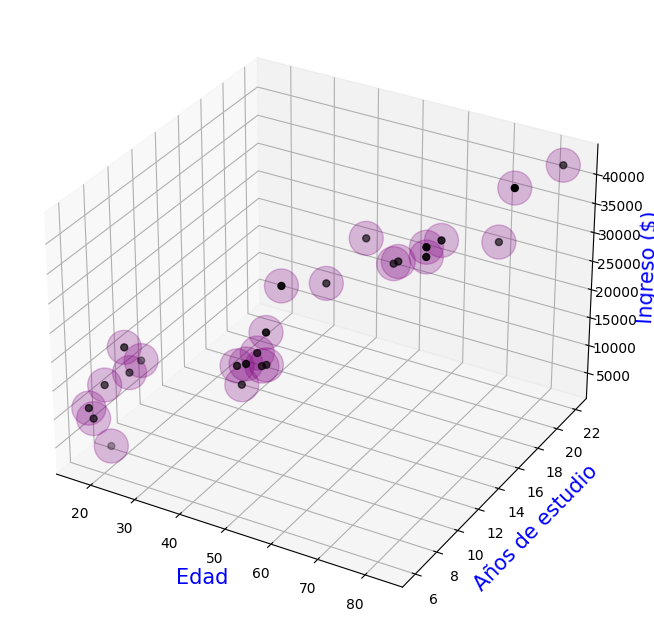

In [15]:
# Grafica tridimensional
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.scatter(datos[:,0], datos[:, 1], datos[:, 2],
           marker="o", c="purple", s=600, alpha=0.25)
ax.scatter(datos[:,0], datos[:, 1], datos[:, 2],
           marker=".", c="black", s=100)

ax.set_xlabel("Edad", fontsize=15, color="blue")
ax.set_ylabel("Años de estudio", fontsize=15, color="blue")
ax.set_zlabel("Ingreso ($)", fontsize=15, color="blue")

plt.show()

Como los datos están en diferentes escalas y queremos aplicar KNN como técnica de imputación, debemos estandarizar o escalar los datos para homogeneizar los datos.

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
escalador = MinMaxScaler().fit(datos)
datos_escalados = escalador.transform(datos)
datos_escalados

array([[0.        , 0.        , 0.20509212],
       [0.01515152, 0.        , 0.16399693],
       [0.01515152, 0.0625    , 0.27080348],
       [0.03030303, 0.0625    , 0.        ],
       [0.04545455, 0.125     , 0.40823951],
       [0.06060606, 0.125     , 0.30110031],
       [0.06060606, 0.1875    , 0.3122825 ],
       [0.34848485, 0.25      , 0.36005629],
       [0.36363636, 0.25      , 0.2819089 ],
       [0.37878788, 0.25      , 0.38068066],
       [0.37878788, 0.3125    , 0.38646366],
       [0.39393939, 0.3125    , 0.33380246],
       [0.40909091, 0.3125    , 0.48955988],
       [0.40909091, 0.3125    , 0.3453173 ],
       [0.42424242, 0.375     , 0.65849539],
       [0.5       , 0.5       , 0.61653019],
       [0.56060606, 0.625     , 0.75649949],
       [0.65151515, 0.625     , 0.67881269],
       [0.66666667, 0.625     , 0.69411464],
       [0.75757576, 0.625     , 0.78999488],
       [0.75757576, 0.625     , 0.74769703],
       [0.77272727, 0.6875    , 0.78541453],
       [0.

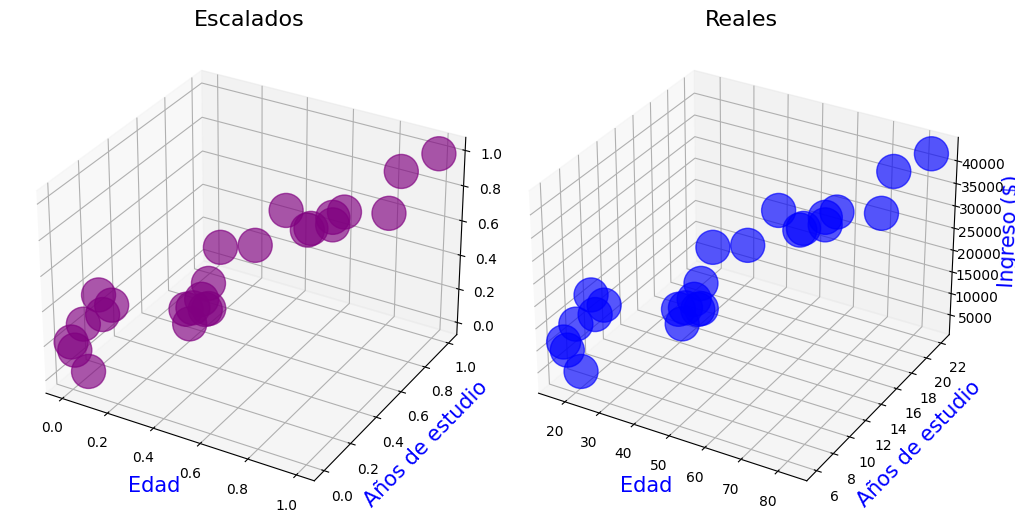

In [24]:
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")

ax1.scatter(datos_escalados[:,0], 
           datos_escalados[:, 1], 
           datos_escalados[:, 2],
           marker="o", c="purple", s=600, alpha=0.65)

ax1.set_xlabel("Edad", fontsize=15, color="blue")
ax1.set_ylabel("Años de estudio", fontsize=15, color="blue")
ax1.set_zlabel("Ingreso ($)", fontsize=15, color="blue")
ax1.set_title("Escalados", fontsize=16)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")

ax2.scatter(datos[:,0], 
           datos[:, 1], 
           datos[:, 2],
           marker="o", c="blue", s=600, alpha=0.65)

ax2.set_xlabel("Edad", fontsize=15, color="blue")
ax2.set_ylabel("Años de estudio", fontsize=15, color="blue")
ax2.set_zlabel("Ingreso ($)", fontsize=15, color="blue")
ax2.set_title("Reales", fontsize=16)

plt.tight_layout()

plt.show()

In [26]:
# Agregamos valores faltantes
faltantes = datos_escalados.copy()
faltantes[[2, 7, 12, 17, 22], 2] = np.nan
faltantes

array([[0.        , 0.        , 0.20509212],
       [0.01515152, 0.        , 0.16399693],
       [0.01515152, 0.0625    ,        nan],
       [0.03030303, 0.0625    , 0.        ],
       [0.04545455, 0.125     , 0.40823951],
       [0.06060606, 0.125     , 0.30110031],
       [0.06060606, 0.1875    , 0.3122825 ],
       [0.34848485, 0.25      ,        nan],
       [0.36363636, 0.25      , 0.2819089 ],
       [0.37878788, 0.25      , 0.38068066],
       [0.37878788, 0.3125    , 0.38646366],
       [0.39393939, 0.3125    , 0.33380246],
       [0.40909091, 0.3125    ,        nan],
       [0.40909091, 0.3125    , 0.3453173 ],
       [0.42424242, 0.375     , 0.65849539],
       [0.5       , 0.5       , 0.61653019],
       [0.56060606, 0.625     , 0.75649949],
       [0.65151515, 0.625     ,        nan],
       [0.66666667, 0.625     , 0.69411464],
       [0.75757576, 0.625     , 0.78999488],
       [0.75757576, 0.625     , 0.74769703],
       [0.77272727, 0.6875    , 0.78541453],
       [0.

### Estimación e imputación de valores faltantes

In [27]:
from sklearn.impute import KNNImputer

In [30]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputer_uni = imputer.fit_transform(faltantes)

imputer = KNNImputer(n_neighbors=5, weights="distance")
imputer_dis = imputer.fit_transform(faltantes)

imputer_uni, imputer_dis
#np.stack((imputer_uni, imputer_dis), axis=1)

(array([[0.        , 0.        , 0.20509212],
        [0.01515152, 0.        , 0.16399693],
        [0.01515152, 0.0625    , 0.21568577],
        [0.03030303, 0.0625    , 0.        ],
        [0.04545455, 0.125     , 0.40823951],
        [0.06060606, 0.125     , 0.30110031],
        [0.06060606, 0.1875    , 0.3122825 ],
        [0.34848485, 0.25      , 0.3456346 ],
        [0.36363636, 0.25      , 0.2819089 ],
        [0.37878788, 0.25      , 0.38068066],
        [0.37878788, 0.3125    , 0.38646366],
        [0.39393939, 0.3125    , 0.33380246],
        [0.40909091, 0.3125    , 0.42095189],
        [0.40909091, 0.3125    , 0.3453173 ],
        [0.42424242, 0.375     , 0.65849539],
        [0.5       , 0.5       , 0.61653019],
        [0.56060606, 0.625     , 0.75649949],
        [0.65151515, 0.625     , 0.75474411],
        [0.66666667, 0.625     , 0.69411464],
        [0.75757576, 0.625     , 0.78999488],
        [0.75757576, 0.625     , 0.74769703],
        [0.77272727, 0.6875    , 0

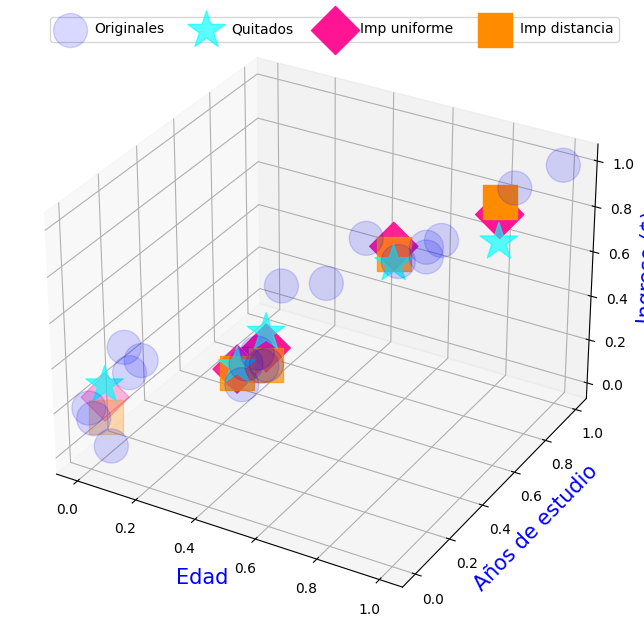

In [33]:
fig = plt.figure(figsize=(8, 8))

filtro = ~np.isnan(faltantes[:,2])

ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.scatter(datos_escalados.T[0][filtro], 
           datos_escalados.T[1][filtro], 
           datos_escalados.T[2][filtro],
           label="Originales",
           marker="o", c="blue", s=600, alpha=0.15)

ax.scatter(datos_escalados.T[0][~filtro], 
           datos_escalados.T[1][~filtro], 
           datos_escalados.T[2][~filtro],
           label="Quitados",
           marker="*", c="cyan", s=800, alpha=0.65)

ax.scatter(imputer_uni.T[0][~filtro], 
           imputer_uni.T[1][~filtro], 
           imputer_uni.T[2][~filtro],
           label="Imp uniforme",
           marker="D", c="deeppink", s=600)

ax.scatter(imputer_dis.T[0][~filtro], 
           imputer_dis.T[1][~filtro], 
           imputer_dis.T[2][~filtro],
           label="Imp distancia",
           marker="s", c="darkorange", s=600)

ax.set_xlabel("Edad", fontsize=15, color="blue")
ax.set_ylabel("Años de estudio", fontsize=15, color="blue")
ax.set_zlabel("Ingreso ($)", fontsize=15, color="blue")
ax.legend(ncol=4)

plt.show()